# **Objective**



**1.   Sales Trend Analysis**

*   Sales Performance by Outlet
*   Sales by Outlet Type
*   Item Type Performance Analysis


**2.   Top product by Sales/Revenue**

**3.   Regional Performance Comparison**

**4.   Trend Across Outlet Types**

**5.   Predictive Modeling for Outlet Sales**




# Dataset

---



In [ ]:
from google.colab import drive
from google.colab import files
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!pwd

/content


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

In [ ]:
file_path = "/content/drive/MyDrive/Data/Time Series/city_day.csv"
df = pd.read_csv(file_path)

NameError: name 'pd' is not defined

In [ ]:
df.shape

(8523, 12)

In [ ]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [ ]:
# Display basic information and the first few rows
df_info = df.info()
df_info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [ ]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


# **Big Mart Sales Analysis Project**

# Data Cleaning

---



In [ ]:
# Copying the dataset to avoid modifying the original
data = df.copy()

NameError: name 'df' is not defined

In [ ]:
# Isolate the column with missing values
obs_data = data['Item_Weight'].values

In [ ]:
import pymc as pm
import arviz as az

# Boolean mask for missing data
missing_mask = np.isnan(obs_data)

with pm.Model() as model:
    # Priors
    mu = pm.Normal("mu", mu=10, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=10)

    # Likelihood for observed values
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=obs_data[~missing_mask])

    # Distribution for missing values
    missing = pm.Normal("missing", mu=mu, sigma=sigma, shape=int(missing_mask.sum()))

    # Sampling from posterior
    trace = pm.sample(1000, tune=1000, target_accept=0.95, chains=2, random_seed=42)

Output()

In [ ]:
# Get the mean of the posterior predictive distribution
imputed_values = trace.posterior['missing'].mean(dim=("chain", "draw")).values

# Fill the missing values back into the dataset
data.loc[missing_mask, 'Item_Weight'] = imputed_values

In [ ]:
data.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Step 1: Encode relevant categorical features
le_outlet_type = LabelEncoder()
le_location_type = LabelEncoder()

data['Outlet_Type_enc'] = le_outlet_type.fit_transform(data['Outlet_Type'])
data['Outlet_Location_Type_enc'] = le_location_type.fit_transform(data['Outlet_Location_Type'])

# Step 2: Split data into known and missing Outlet_Size
train = data[data['Outlet_Size'].notna()]
test = data[data['Outlet_Size'].isna()]

# Step 3: Train a classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(train[['Outlet_Type_enc', 'Outlet_Location_Type_enc']], train['Outlet_Size'])

# Step 4: Predict missing values
predicted_sizes = clf.predict(test[['Outlet_Type_enc', 'Outlet_Location_Type_enc']])

# Step 5: Fill in the missing values
data.loc[data['Outlet_Size'].isna(), 'Outlet_Size'] = predicted_sizes

# Step 6: (Optional) Drop temporary encoding columns
data.drop(['Outlet_Type_enc', 'Outlet_Location_Type_enc'], axis=1, inplace=True)

# Final check
print("Missing values remaining in Outlet_Size:", data['Outlet_Size'].isna().sum())


Missing values remaining in Outlet_Size: 0


In [ ]:
data.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [ ]:
df_cleaned = data.copy()

In [ ]:
df_cleaned.replace({'Item_Fat_Content':{'LF':'Low Fat','low fat':'Low Fat','reg':'Regular'}}, inplace= True)

In [ ]:
# Plot settings
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

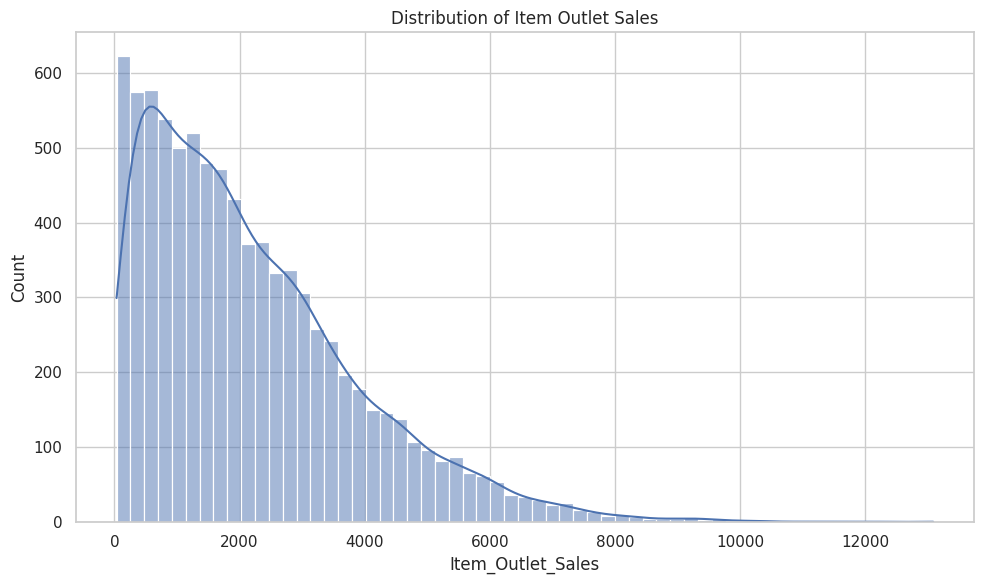

In [ ]:
# Univariate analysis: Distribution of Item_Outlet_Sales
sales_plot = sns.histplot(df_cleaned['Item_Outlet_Sales'],kde=True)
sales_plot.set_title("Distribution of Item Outlet Sales")
plt.tight_layout()
plt.show()


The distribution of Item Outlet Sales is right-skewed (tail on the right), meaning:

* Most items have low to moderate sales, while a few items perform exceptionally well in terms of sales volume.
* A high number of items sell in the range of approximately ₹500 to ₹1500.

array([[<Axes: title={'center': 'Item_Weight'}>,
        <Axes: title={'center': 'Item_Visibility'}>],
       [<Axes: title={'center': 'Item_MRP'}>,
        <Axes: title={'center': 'Outlet_Establishment_Year'}>],
       [<Axes: title={'center': 'Item_Outlet_Sales'}>, <Axes: >]],
      dtype=object)

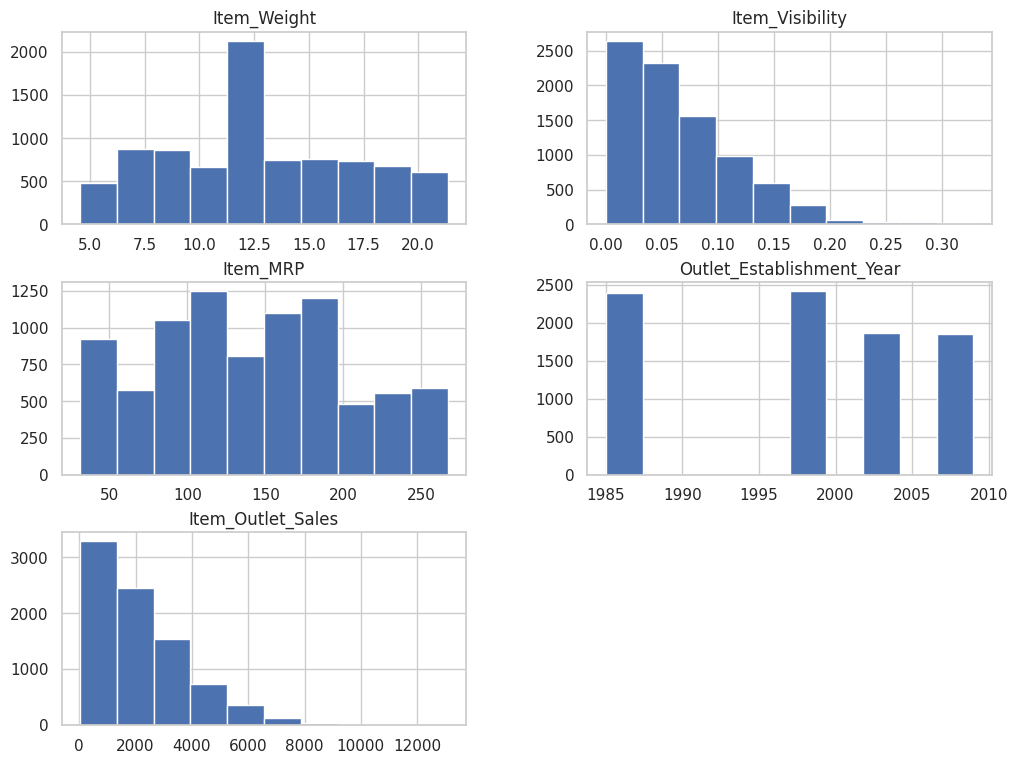

In [ ]:
df_cleaned.hist(figsize=(12,9))

<Axes: xlabel='Item_MRP', ylabel='Item_Outlet_Sales'>

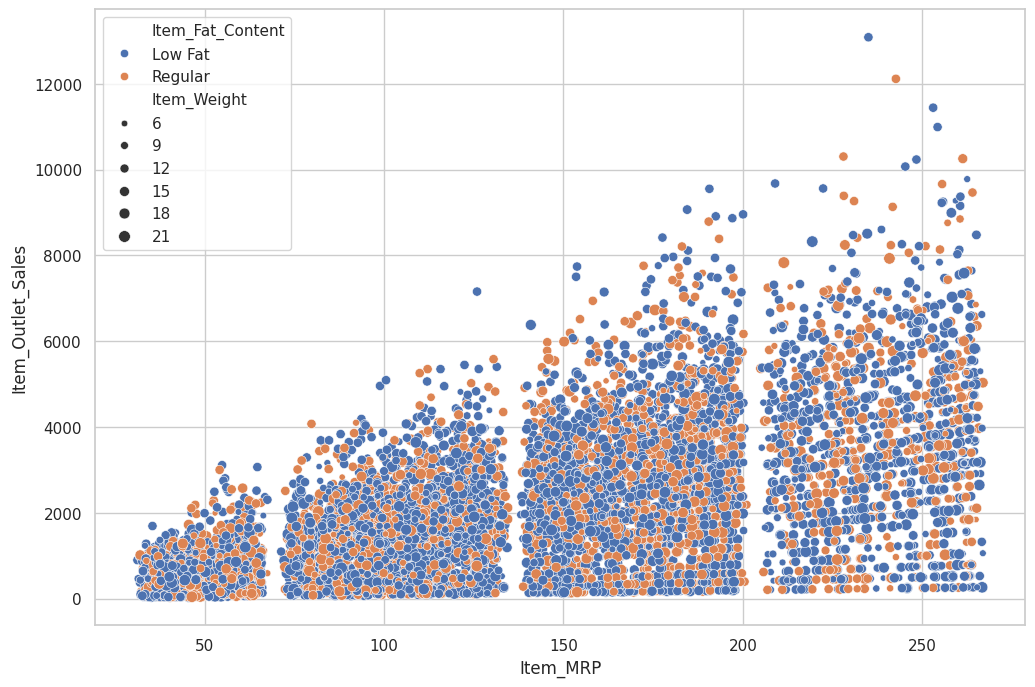

In [ ]:
fig,axes=plt.subplots(1,1,figsize=(12,8))
sns.scatterplot(x='Item_MRP',y='Item_Outlet_Sales',hue='Item_Fat_Content',size='Item_Weight',data=df_cleaned)

# 1. Sales Trend Analysis

1. Sales Performance by Outlet

Sales by Outlets:

  Outlet_Identifier   Total_Sales  sum_lakhs
0            OUT010  1.883402e+05   1.883402
1            OUT013  2.142664e+06  21.426636
2            OUT017  2.167465e+06  21.674653
3            OUT018  1.851823e+06  18.518228
4            OUT019  1.796941e+05   1.796941
5            OUT027  3.453926e+06  34.539261
6            OUT035  2.268123e+06  22.681229
7            OUT045  2.036725e+06  20.367255
8            OUT046  2.118395e+06  21.183952
9            OUT049  2.183970e+06  21.839698


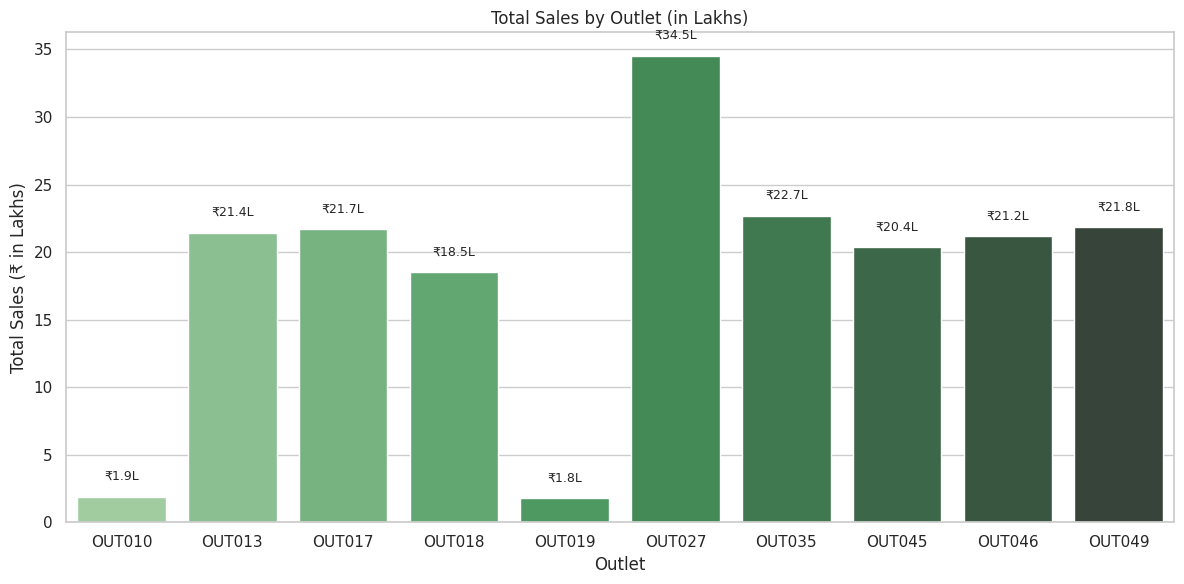

In [ ]:
outlet_sales = df_cleaned.groupby('Outlet_Identifier')['Item_Outlet_Sales'].sum().reset_index()
outlet_sales = outlet_sales.sort_values(by='Outlet_Identifier').copy()
outlet_sales.rename(columns={'Item_Outlet_Sales': 'Total_Sales'}, inplace=True)

outlet_sales['sum_lakhs'] = outlet_sales['Total_Sales'] / 1e5
print('Sales by Outlets:\n')
print(outlet_sales)

# Plotting
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

total_plot = sns.barplot(data=outlet_sales, x='Outlet_Identifier', y='sum_lakhs', palette="Greens_d")
plt.title('Total Sales by Outlet (in Lakhs)')
plt.xlabel('Outlet')
plt.ylabel('Total Sales (₹ in Lakhs)')

# Annotate bars
for p in total_plot.patches:
    height = p.get_height()
    if not np.isnan(height):
        total_plot.annotate(f'₹{height:,.1f}L',
                            (p.get_x() + p.get_width() / 2, height + 1),
                            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

2. Sales by Outlet Type

Sales by Outlet Type and Outlet Location Type :

         Outlet_Type Outlet_Location_Type         mean           sum  \
0      Grocery Store               Tier 1   340.329723  1.796941e+05   
1      Grocery Store               Tier 3   339.351662  1.883402e+05   
2  Supermarket Type1               Tier 1  2313.099451  4.302365e+06   
3  Supermarket Type1               Tier 2  2323.990559  6.472314e+06   
4  Supermarket Type1               Tier 3  2298.995256  2.142664e+06   
5  Supermarket Type2               Tier 3  1995.498739  1.851823e+06   
6  Supermarket Type3               Tier 3  3694.038558  3.453926e+06   

   sum_lakhs  
0   1.796941  
1   1.883402  
2  43.023650  
3  64.723137  
4  21.426636  
5  18.518228  
6  34.539261  


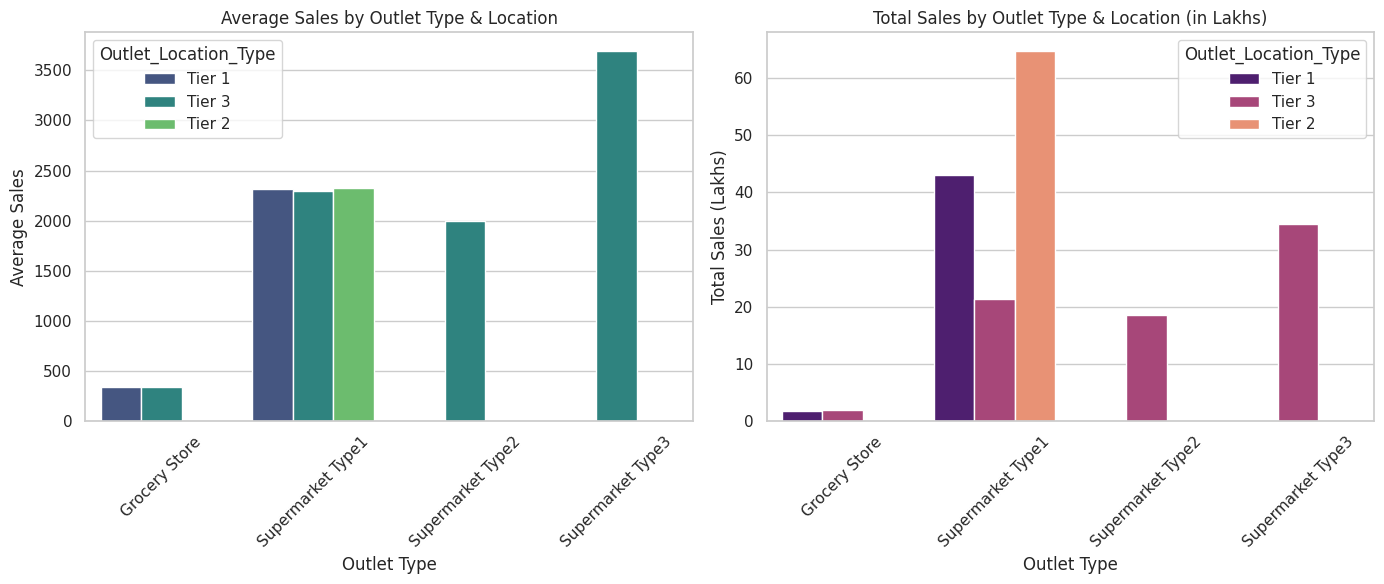

In [ ]:
outlet_group = df_cleaned.groupby(['Outlet_Type', 'Outlet_Location_Type'])['Item_Outlet_Sales'].agg(['mean', 'sum']).reset_index()
outlet_group['sum_lakhs'] = outlet_group['sum']/1e5

print('Sales by Outlet Type and Outlet Location Type :\n')
print(outlet_group)

sns.set(style="whitegrid")
plt.figure(figsize=(14, 6))

# Average Sales by Outlet Type and Location
plt.subplot(1, 2, 1)
sns.barplot(data=outlet_group, x='Outlet_Type', y='mean', hue='Outlet_Location_Type', palette='viridis')
plt.title('Average Sales by Outlet Type & Location')
plt.xlabel('Outlet Type')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)

# Total Sales by Outlet Type and Location (in Lakhs)
plt.subplot(1, 2, 2)
sns.barplot(data=outlet_group, x='Outlet_Type', y='sum_lakhs', hue='Outlet_Location_Type', palette='magma')
plt.title('Total Sales by Outlet Type & Location (in Lakhs)')
plt.xlabel('Outlet Type')
plt.ylabel('Total Sales (Lakhs)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

3. Item Type Performance Analysis

Total Sales per Item Type :
                                sum  sum_lakhs
Item_Type                                     
Fruits and Vegetables  2.820060e+06  28.200598
Snack Foods            2.732786e+06  27.327861
Household              2.055494e+06  20.554937
Frozen Foods           1.825735e+06  18.257348
Dairy                  1.522594e+06  15.225941
Canned                 1.444151e+06  14.441515
Baking Goods           1.265525e+06  12.655253
Health and Hygiene     1.045200e+06  10.452001
Meat                   9.175656e+05   9.175656
Soft Drinks            8.928977e+05   8.928977
Breads                 5.532372e+05   5.532372
Hard Drinks            4.577934e+05   4.577934
Starchy Foods          3.514013e+05   3.514013
Others                 3.255176e+05   3.255176
Breakfast              2.322990e+05   2.322990
Seafood                1.488682e+05   1.488682


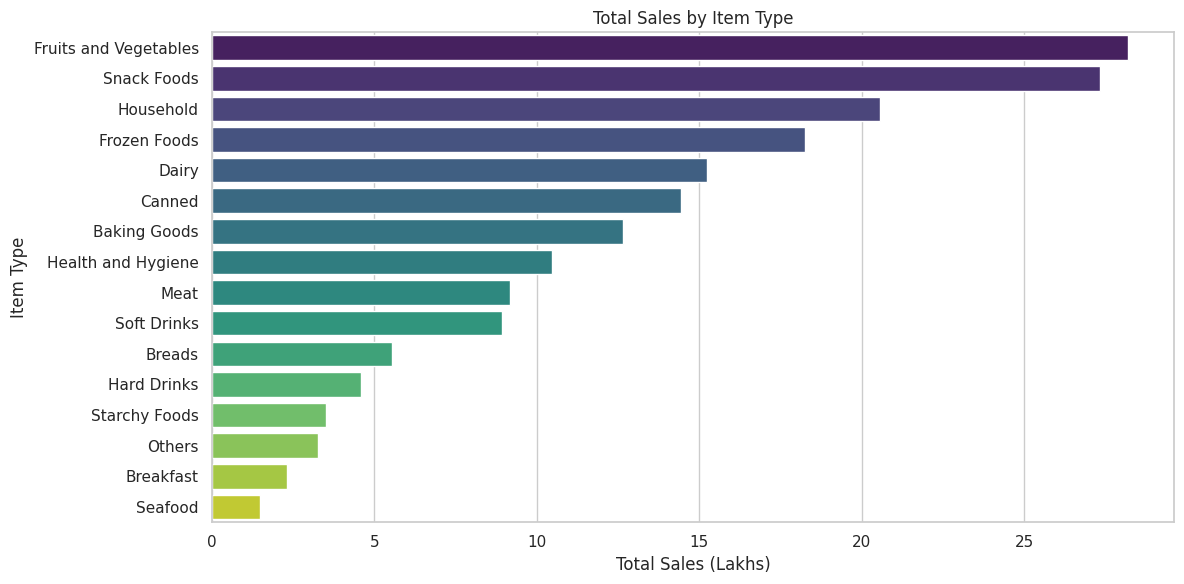

In [ ]:
item_sales = df_cleaned.groupby('Item_Type')['Item_Outlet_Sales'].agg(['sum']).sort_values(by='sum', ascending=False)
item_sales['sum_lakhs'] = item_sales['sum'] / 1e5  # 1 lakh = 100,000

print('Total Sales per Item Type :')
print(item_sales)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=item_sales['sum_lakhs'], y=item_sales.index, palette="viridis")
plt.title("Total Sales by Item Type")
plt.xlabel("Total Sales (Lakhs)")
plt.ylabel("Item Type")
plt.tight_layout()
plt.show()

# 2. Top product by Sales/Revenue

Top 10 Products by Total Sales:
      Item_Identifier              Item_Type  Total_Sales
1210           FDY55  Fruits and Vegetables   42661.8008
156            FDA15                  Dairy   41584.5364
1230           FDZ20  Fruits and Vegetables   40185.0248
359            FDF05           Frozen Foods   36555.7490
148            FDA04           Frozen Foods   35741.4756
544            FDK03                  Dairy   34843.9772
1454           NCQ06              Household   34680.1904
1464           NCQ53     Health and Hygiene   34508.4140
538            FDJ55                   Meat   33531.0196
305            FDD44  Fruits and Vegetables   32723.4042


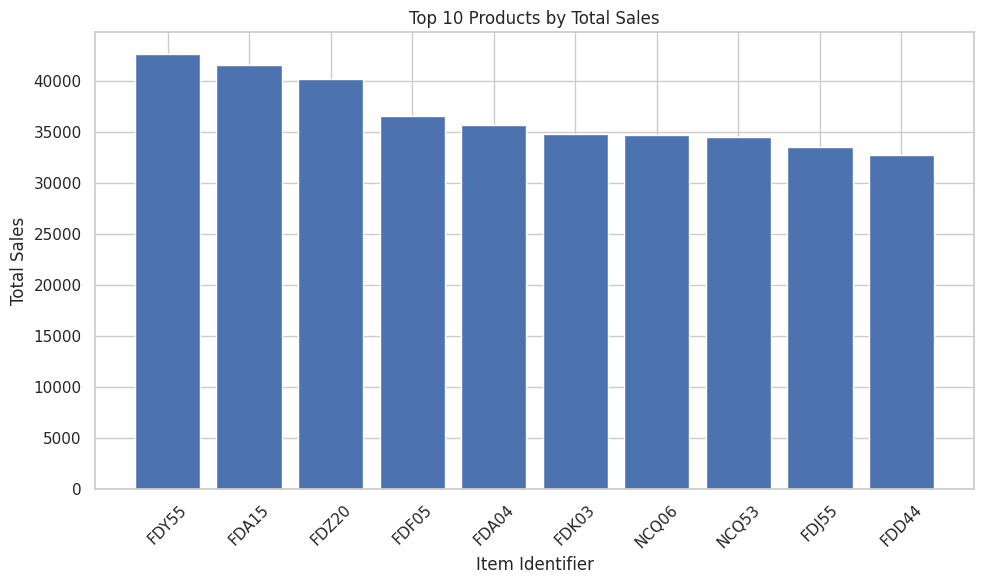

In [ ]:
product_sales = (
    df_cleaned
    .groupby(['Item_Identifier', 'Item_Type'], as_index=False)['Item_Outlet_Sales']
    .sum()
    .rename(columns={'Item_Outlet_Sales': 'Total_Sales'})
)
top_products = product_sales.sort_values(by='Total_Sales', ascending=False).head(10)
print("Top 10 Products by Total Sales:\n", top_products)

# Plot a bar graph of the top products
plt.figure(figsize=(10, 6))
plt.bar(top_products['Item_Identifier'], top_products['Total_Sales'])
plt.xlabel('Item Identifier')
plt.ylabel('Total Sales')
plt.title('Top 10 Products by Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Regional Performance Comparison

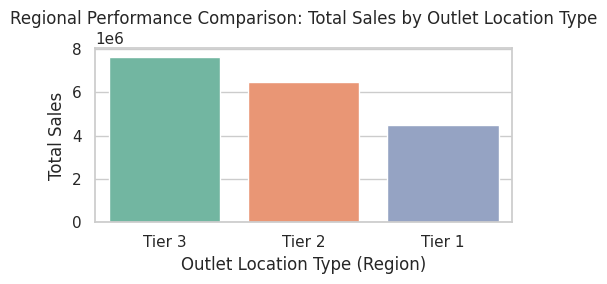

  Outlet_Location_Type   Total_Sales
0               Tier 3  7.636753e+06
1               Tier 2  6.472314e+06
2               Tier 1  4.482059e+06


In [ ]:
#Total Sales by Region (Regional Performance Comparison)
regional_sales = df.groupby("Outlet_Location_Type")["Item_Outlet_Sales"].sum().sort_values(ascending=False)

# Plotting
plt.figure(figsize=(5,3))
sns.barplot(x=regional_sales.index, y=regional_sales.values, palette='Set2')
plt.title('Regional Performance Comparison: Total Sales by Outlet Location Type')
plt.xlabel('Outlet Location Type (Region)')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

# Summary table
regional_sales_summary = regional_sales.reset_index().rename(columns={'Item_Outlet_Sales': 'Total_Sales'})
print(regional_sales_summary)

Outlet_Location_Type
Tier 2    2323.990559
Tier 3    2279.627651
Tier 1    1876.909159
Name: Item_Outlet_Sales, dtype: float64


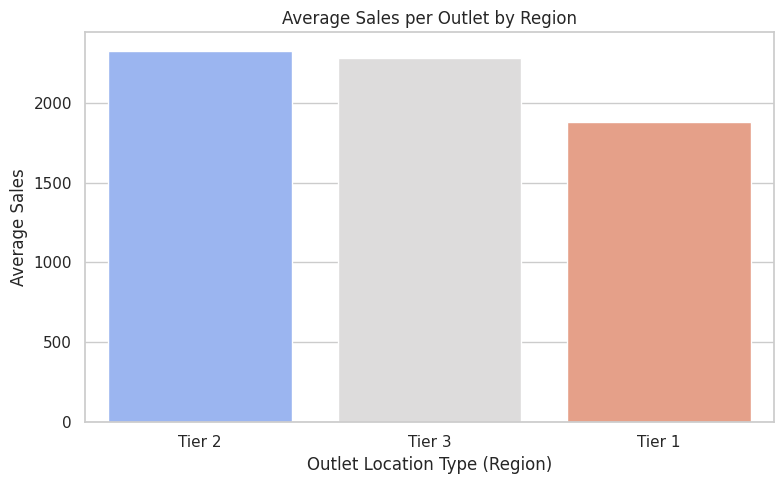

In [ ]:
# Average Sales per Region
avg_sales_region = df.groupby('Outlet_Location_Type')['Item_Outlet_Sales'].mean().sort_values(ascending=False)
print(avg_sales_region)

# Plotting
plt.figure(figsize=(8,5))
sns.barplot(x=avg_sales_region.index, y=avg_sales_region.values, palette='coolwarm')
plt.title('Average Sales per Outlet by Region')
plt.xlabel('Outlet Location Type (Region)')
plt.ylabel('Average Sales')
plt.tight_layout()
plt.show()

Outlet_Location_Type
Tier 1    3
Tier 2    3
Tier 3    4
Name: Outlet_Identifier, dtype: int64


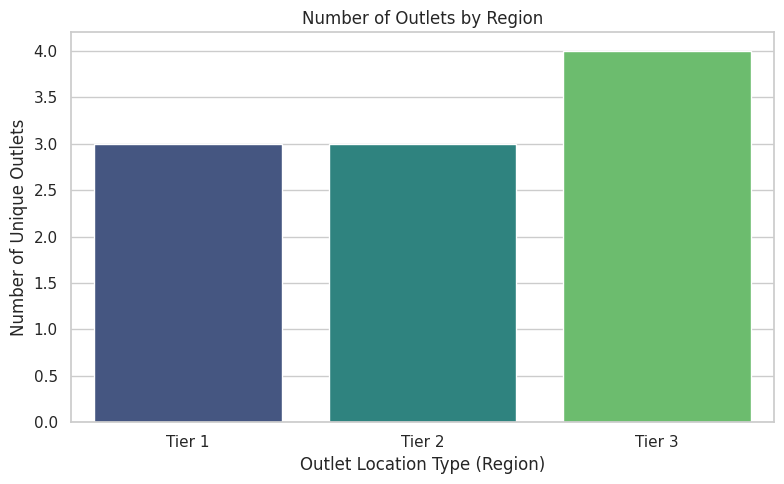

In [ ]:
# Number of Outlets per Region
outlet_count_region = df.groupby('Outlet_Location_Type')['Outlet_Identifier'].nunique()
print(outlet_count_region)

# Plotting
plt.figure(figsize=(8,5))
sns.barplot(x=outlet_count_region.index, y=outlet_count_region.values, palette='viridis')
plt.title('Number of Outlets by Region')
plt.xlabel('Outlet Location Type (Region)')
plt.ylabel('Number of Unique Outlets')
plt.tight_layout()
plt.show()

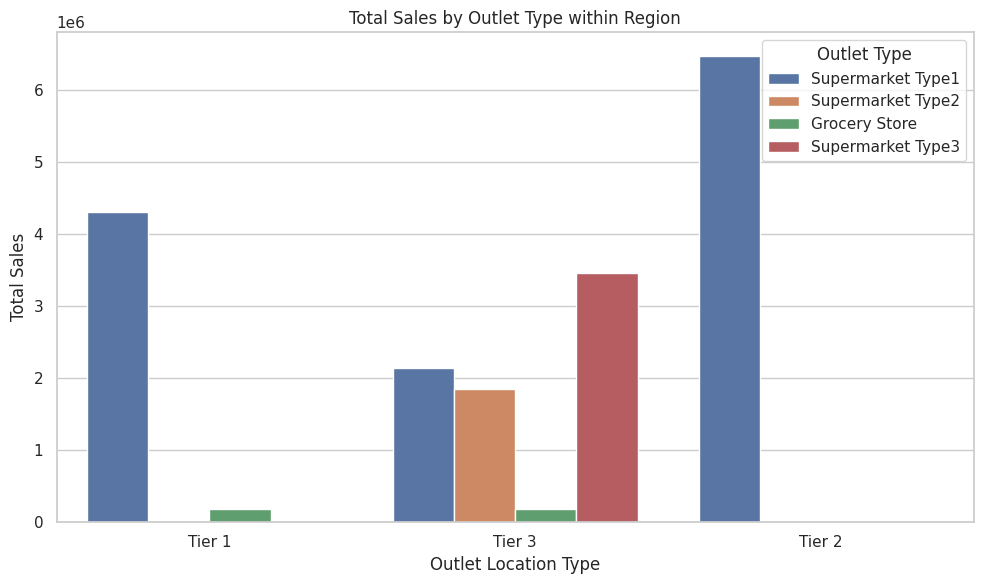

In [ ]:
# Total Sales by Outlet Type within each Region
plt.figure(figsize=(10,6))
sns.barplot(x='Outlet_Location_Type', y='Item_Outlet_Sales', hue='Outlet_Type', data=df, estimator=sum, ci=None)
plt.title('Total Sales by Outlet Type within Region')
plt.xlabel('Outlet Location Type')
plt.ylabel('Total Sales')
plt.legend(title='Outlet Type')
plt.tight_layout()
plt.show()

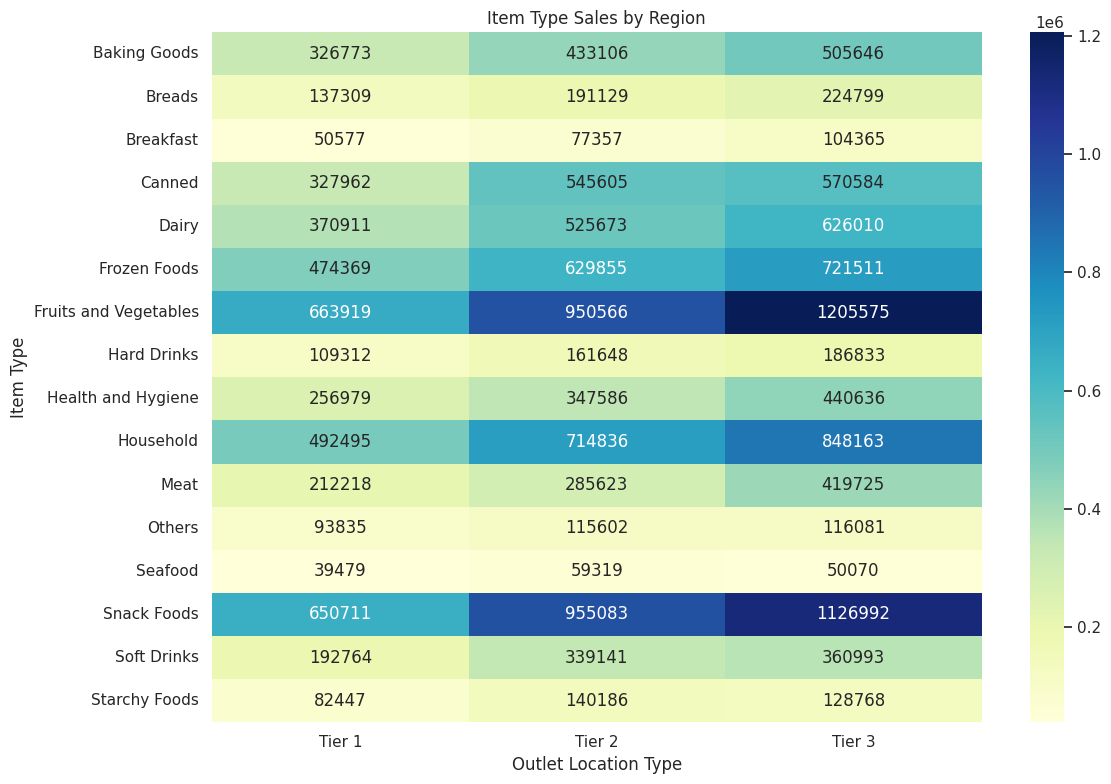

In [ ]:
#Heatmap: Item Type Sales by Region

pivot_table = pd.pivot_table(df, values='Item_Outlet_Sales',
                             index='Item_Type',
                             columns='Outlet_Location_Type',
                             aggfunc='sum',
                             fill_value=0)

plt.figure(figsize=(12,8))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Item Type Sales by Region')
plt.xlabel('Outlet Location Type')
plt.ylabel('Item Type')
plt.tight_layout()
plt.show()

# 4. Trend Across Outlet type

Total Sales by Product Type in Outlet:  OUT010
   Outlet_Identifier              Item_Type  Item_Outlet_Sales
13            OUT010            Snack Foods         25942.8970
9             OUT010              Household         25550.0750
6             OUT010  Fruits and Vegetables         24548.0460
5             OUT010           Frozen Foods         17942.6442
4             OUT010                  Dairy         15307.4078
10            OUT010                   Meat         13580.9884
8             OUT010     Health and Hygiene         13570.3356
0             OUT010           Baking Goods         10693.4138
14            OUT010            Soft Drinks          9441.0440
3             OUT010                 Canned          9019.5926
1             OUT010                 Breads          7657.3658
2             OUT010              Breakfast          4081.3540
7             OUT010            Hard Drinks          4067.3722
11            OUT010                 Others          3256.4278
15      

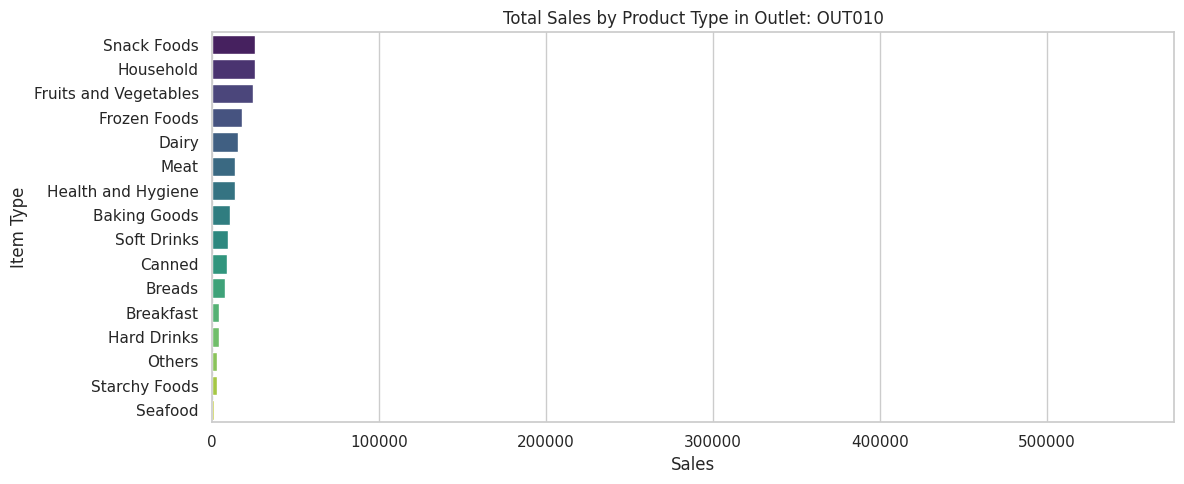

Total Sales by Product Type in Outlet:  OUT013
   Outlet_Identifier              Item_Type  Item_Outlet_Sales
22            OUT013  Fruits and Vegetables        341526.7706
29            OUT013            Snack Foods        309246.1234
25            OUT013              Household        248046.4532
21            OUT013           Frozen Foods        203696.8494
20            OUT013                  Dairy        196254.5370
16            OUT013           Baking Goods        149715.7828
19            OUT013                 Canned        143732.2382
24            OUT013     Health and Hygiene        119135.5888
30            OUT013            Soft Drinks        115234.6666
26            OUT013                   Meat         95200.0788
23            OUT013            Hard Drinks         54362.5700
17            OUT013                 Breads         52018.2882
31            OUT013          Starchy Foods         43753.0470
27            OUT013                 Others         35238.1308
18      

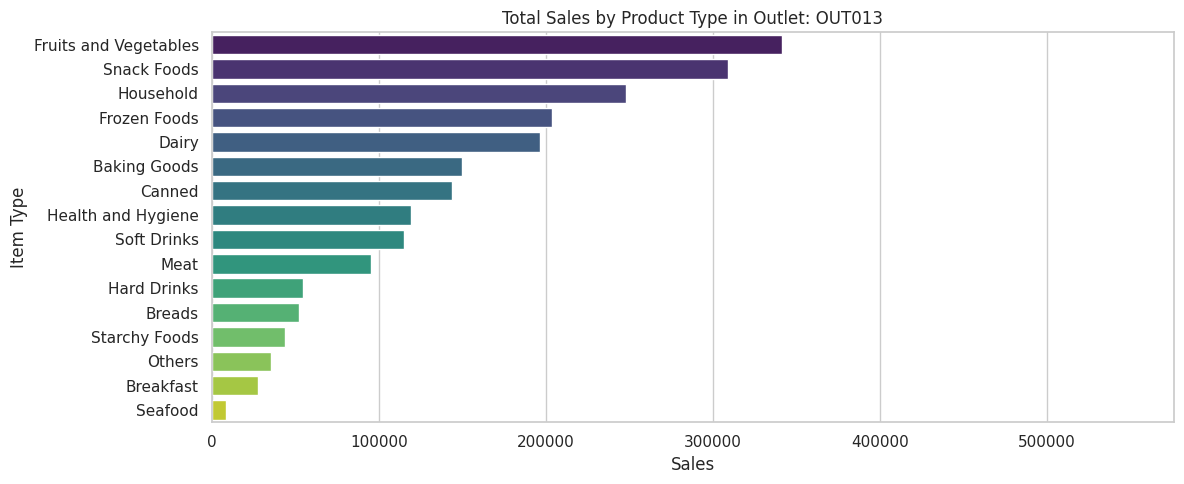

Total Sales by Product Type in Outlet:  OUT017
   Outlet_Identifier              Item_Type  Item_Outlet_Sales
38            OUT017  Fruits and Vegetables        319504.1040
45            OUT017            Snack Foods        311071.0812
37            OUT017           Frozen Foods        239347.1104
41            OUT017              Household        222526.3392
36            OUT017                  Dairy        185955.2768
35            OUT017                 Canned        175853.0934
32            OUT017           Baking Goods        147731.0330
40            OUT017     Health and Hygiene        124751.6118
46            OUT017            Soft Drinks        123710.3006
42            OUT017                   Meat         96822.6334
39            OUT017            Hard Drinks         55432.5106
33            OUT017                 Breads         49008.8722
47            OUT017          Starchy Foods         43893.5308
43            OUT017                 Others         37388.6648
34      

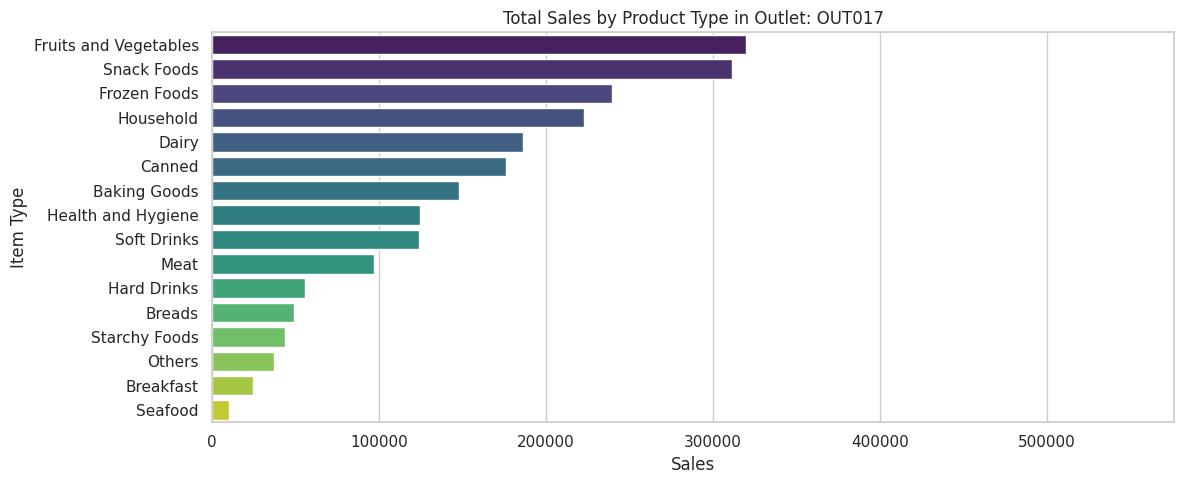

Total Sales by Product Type in Outlet:  OUT018
   Outlet_Identifier              Item_Type  Item_Outlet_Sales
61            OUT018            Snack Foods        278714.5328
54            OUT018  Fruits and Vegetables        263471.7076
57            OUT018              Household        196267.1872
53            OUT018           Frozen Foods        183599.0106
52            OUT018                  Dairy        152130.6394
51            OUT018                 Canned        145681.7006
48            OUT018           Baking Goods        121065.0772
56            OUT018     Health and Hygiene        108845.6498
58            OUT018                   Meat         94655.4544
62            OUT018            Soft Drinks         88495.4728
49            OUT018                 Breads         54604.9212
55            OUT018            Hard Drinks         49445.6370
59            OUT018                 Others         37072.4098
63            OUT018          Starchy Foods         33110.8998
50      

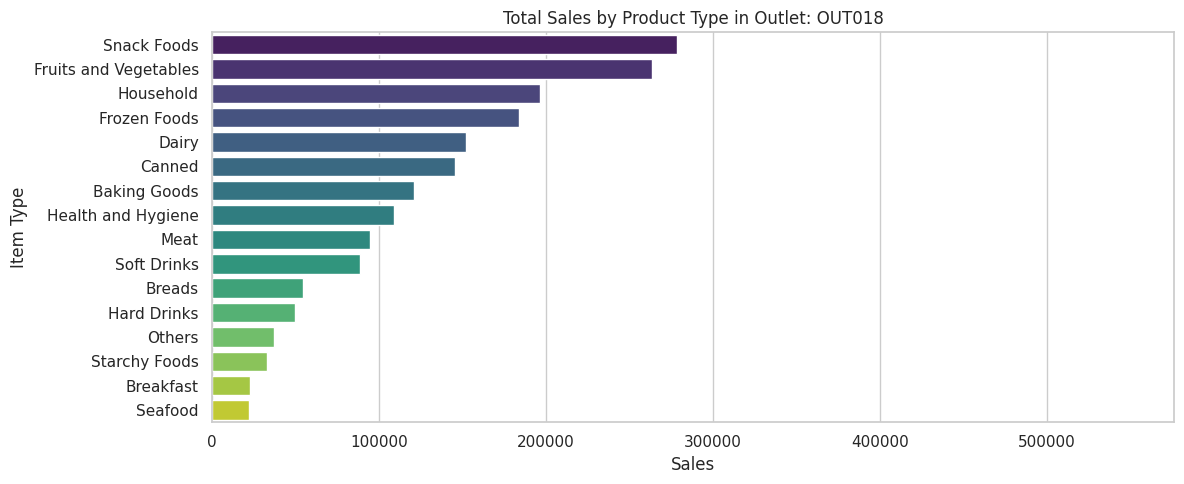

Total Sales by Product Type in Outlet:  OUT019
   Outlet_Identifier              Item_Type  Item_Outlet_Sales
77            OUT019            Snack Foods         25653.2740
70            OUT019  Fruits and Vegetables         24054.0224
73            OUT019              Household         18157.0318
67            OUT019                 Canned         16739.5436
68            OUT019                  Dairy         16144.3184
69            OUT019           Frozen Foods         15252.8122
64            OUT019           Baking Goods         14133.6024
74            OUT019                   Meat         11995.7186
72            OUT019     Health and Hygiene         10945.0862
78            OUT019            Soft Drinks          9113.4704
65            OUT019                 Breads          4947.5598
75            OUT019                 Others          4522.1136
66            OUT019              Breakfast          3762.4358
71            OUT019            Hard Drinks          1768.3648
76      

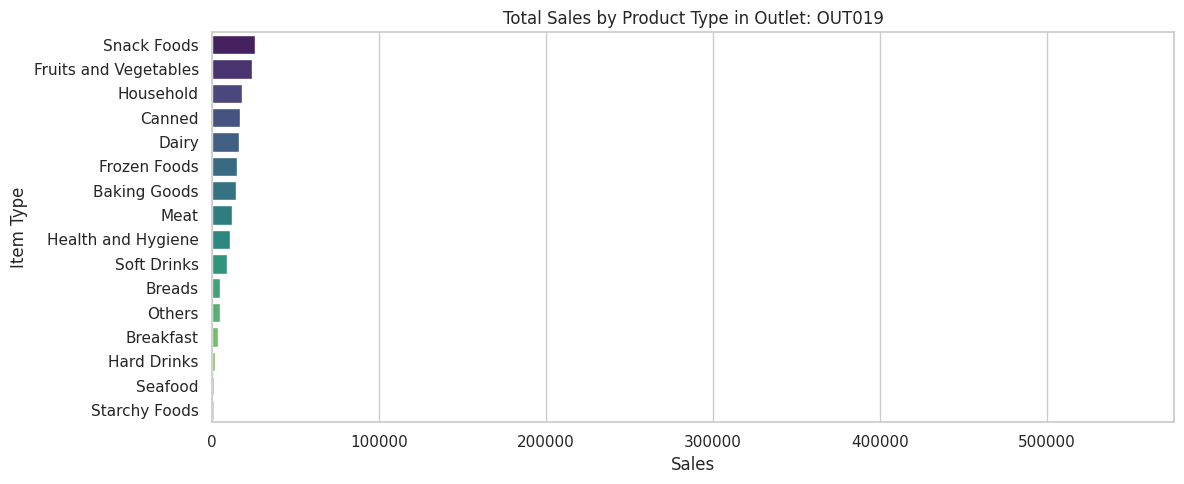

Total Sales by Product Type in Outlet:  OUT027
   Outlet_Identifier              Item_Type  Item_Outlet_Sales
86            OUT027  Fruits and Vegetables        576028.1886
93            OUT027            Snack Foods        513088.1172
89            OUT027              Household        378299.5704
85            OUT027           Frozen Foods        316272.3108
83            OUT027                 Canned        272150.4106
84            OUT027                  Dairy        262317.2104
80            OUT027           Baking Goods        224172.1968
90            OUT027                   Meat        216288.4590
88            OUT027     Health and Hygiene        199084.1870
94            OUT027            Soft Drinks        147822.2476
81            OUT027                 Breads        110518.8052
87            OUT027            Hard Drinks         78957.8878
82            OUT027              Breakfast         50432.3526
95            OUT027          Starchy Foods         49170.6616
91      

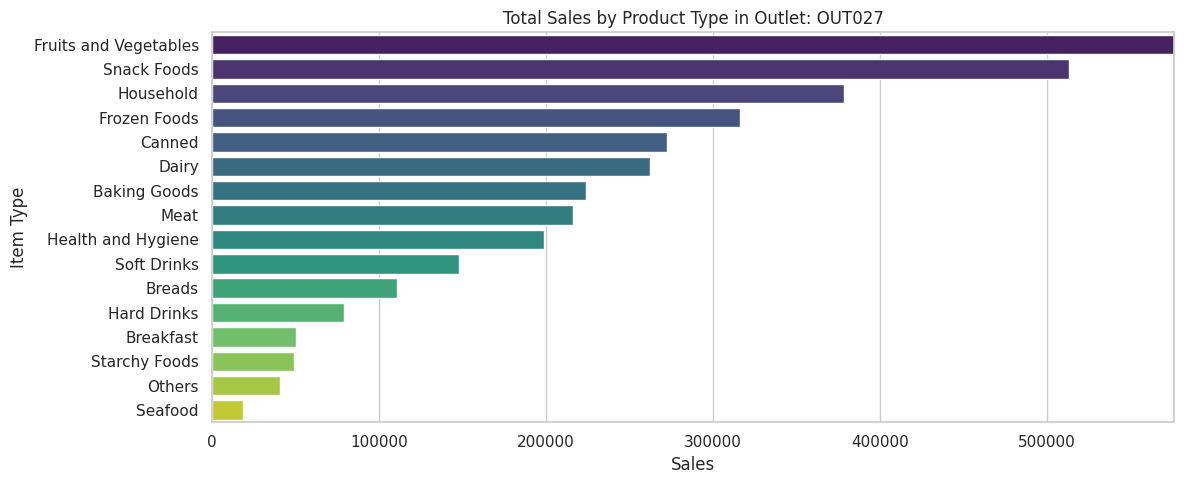

Total Sales by Product Type in Outlet:  OUT035
    Outlet_Identifier              Item_Type  Item_Outlet_Sales
109            OUT035            Snack Foods        355573.8190
102            OUT035  Fruits and Vegetables        304647.4428
105            OUT035              Household        269852.7348
101            OUT035           Frozen Foods        213487.4384
99             OUT035                 Canned        195444.2584
100            OUT035                  Dairy        185067.7654
96             OUT035           Baking Goods        135005.5976
104            OUT035     Health and Hygiene        118230.7666
106            OUT035                   Meat        107193.8000
110            OUT035            Soft Drinks        106751.0430
97             OUT035                 Breads         76456.4772
111            OUT035          Starchy Foods         57945.9056
103            OUT035            Hard Drinks         49941.6580
107            OUT035                 Others         3804

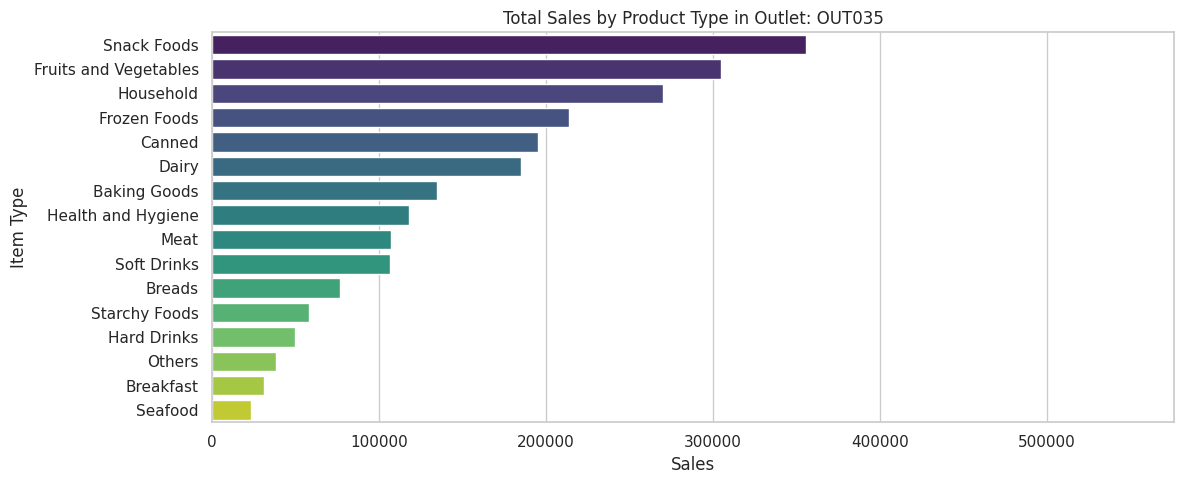

Total Sales by Product Type in Outlet:  OUT045
    Outlet_Identifier              Item_Type  Item_Outlet_Sales
118            OUT045  Fruits and Vegetables        326414.4422
125            OUT045            Snack Foods        288438.5418
121            OUT045              Household        222456.4302
117            OUT045           Frozen Foods        177020.2408
115            OUT045                 Canned        174307.7716
116            OUT045                  Dairy        154650.0266
112            OUT045           Baking Goods        150368.9326
126            OUT045            Soft Drinks        108679.1998
120            OUT045     Health and Hygiene        104603.1722
122            OUT045                   Meat         81606.4402
113            OUT045                 Breads         65663.8592
119            OUT045            Hard Drinks         56274.0818
123            OUT045                 Others         40165.0508
127            OUT045          Starchy Foods         3834

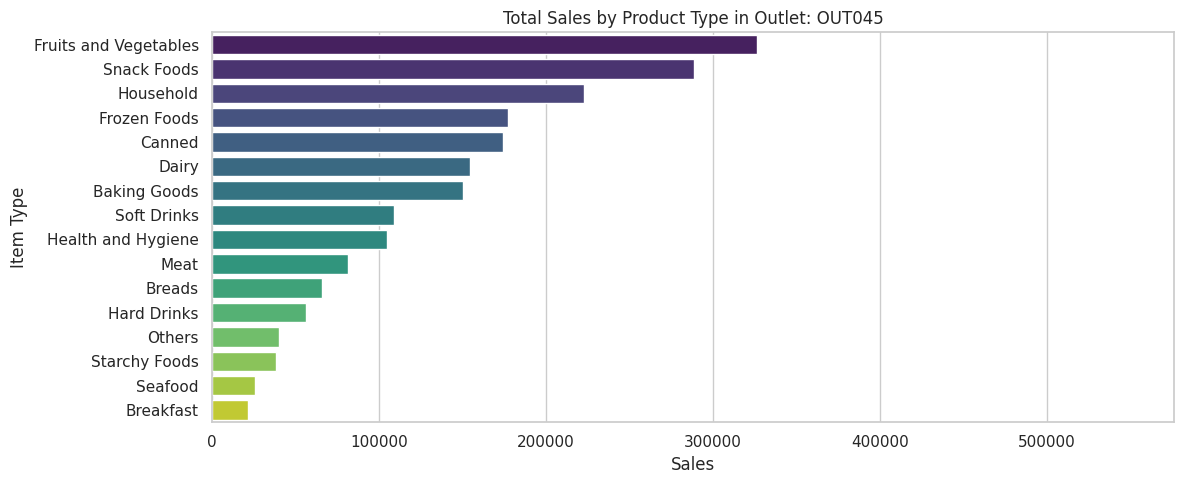

Total Sales by Product Type in Outlet:  OUT046
    Outlet_Identifier              Item_Type  Item_Outlet_Sales
134            OUT046  Fruits and Vegetables        304751.3076
141            OUT046            Snack Foods        274813.6106
133            OUT046           Frozen Foods        243236.7140
137            OUT046              Household        219520.2522
132            OUT046                  Dairy        175086.0918
128            OUT046           Baking Goods        173376.3174
131            OUT046                 Canned        173084.6970
136            OUT046     Health and Hygiene        133189.2952
138            OUT046                   Meat         95072.2452
142            OUT046            Soft Drinks         86064.6370
129            OUT046                 Breads         71870.4468
135            OUT046            Hard Drinks         44615.9238
139            OUT046                 Others         41540.5936
143            OUT046          Starchy Foods         3925

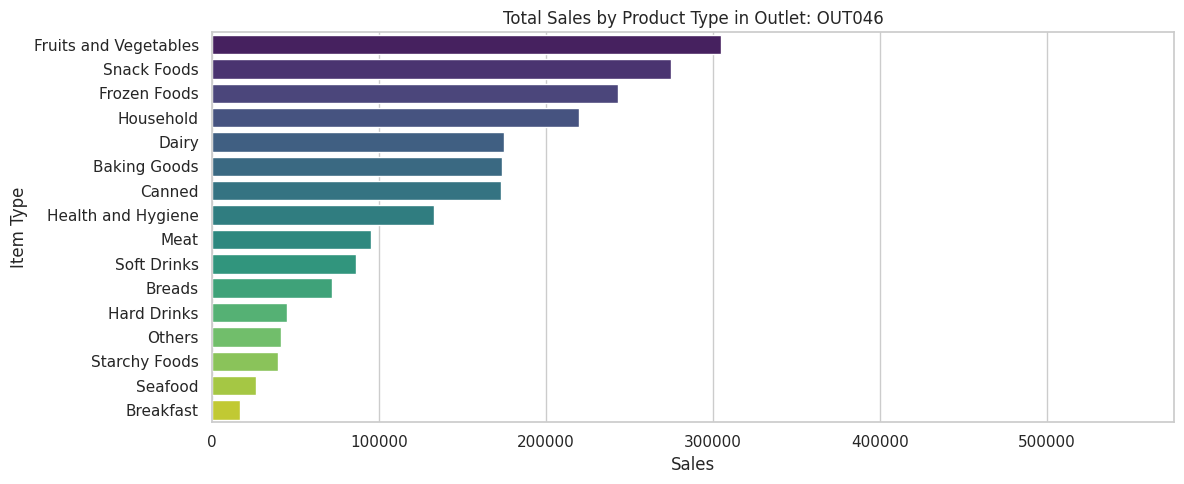

Total Sales by Product Type in Outlet:  OUT049
    Outlet_Identifier              Item_Type  Item_Outlet_Sales
157            OUT049            Snack Foods        350244.0900
150            OUT049  Fruits and Vegetables        335113.7850
153            OUT049              Household        254817.6392
149            OUT049           Frozen Foods        215879.6578
148            OUT049                  Dairy        179680.7776
144            OUT049           Baking Goods        139263.3886
147            OUT049                 Canned        138138.1866
152            OUT049     Health and Hygiene        112844.4446
154            OUT049                   Meat        105149.7940
158            OUT049            Soft Drinks         97585.6402
151            OUT049            Hard Drinks         62927.4212
145            OUT049                 Breads         60490.5932
155            OUT049                 Others         47772.4816
159            OUT049          Starchy Foods         4201

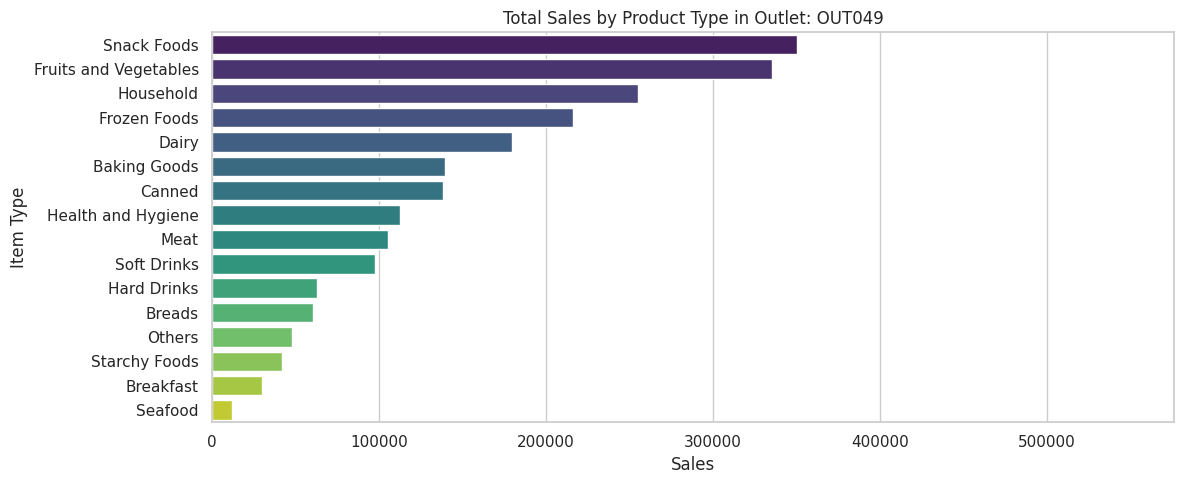

In [ ]:
# Group by Outlet and Item Type and sum sales
grouped = df_cleaned.groupby(['Outlet_Identifier', 'Item_Type'])['Item_Outlet_Sales'].sum().reset_index()

# Get all unique outlets
outlets = grouped['Outlet_Identifier'].unique()

# Get global max sales for x-axis consistency
max_sales = grouped['Item_Outlet_Sales'].max()

# Loop through each outlet and plot
for outlet in outlets:
    plt.figure(figsize=(12, 5))
    data = grouped[grouped['Outlet_Identifier'] == outlet].sort_values(by='Item_Outlet_Sales', ascending=False)

    sns.barplot(x='Item_Outlet_Sales', y='Item_Type', data=data, palette='viridis')

    plt.title(f'Total Sales by Product Type in Outlet: {outlet}')
    plt.xlabel('Sales')
    plt.ylabel('Item Type')

    print("Total Sales by Product Type in Outlet: ",outlet)
    print(data)

    # Set fixed x-axis limit for all plots
    plt.xlim(0, max_sales)

    plt.tight_layout()
    plt.show()

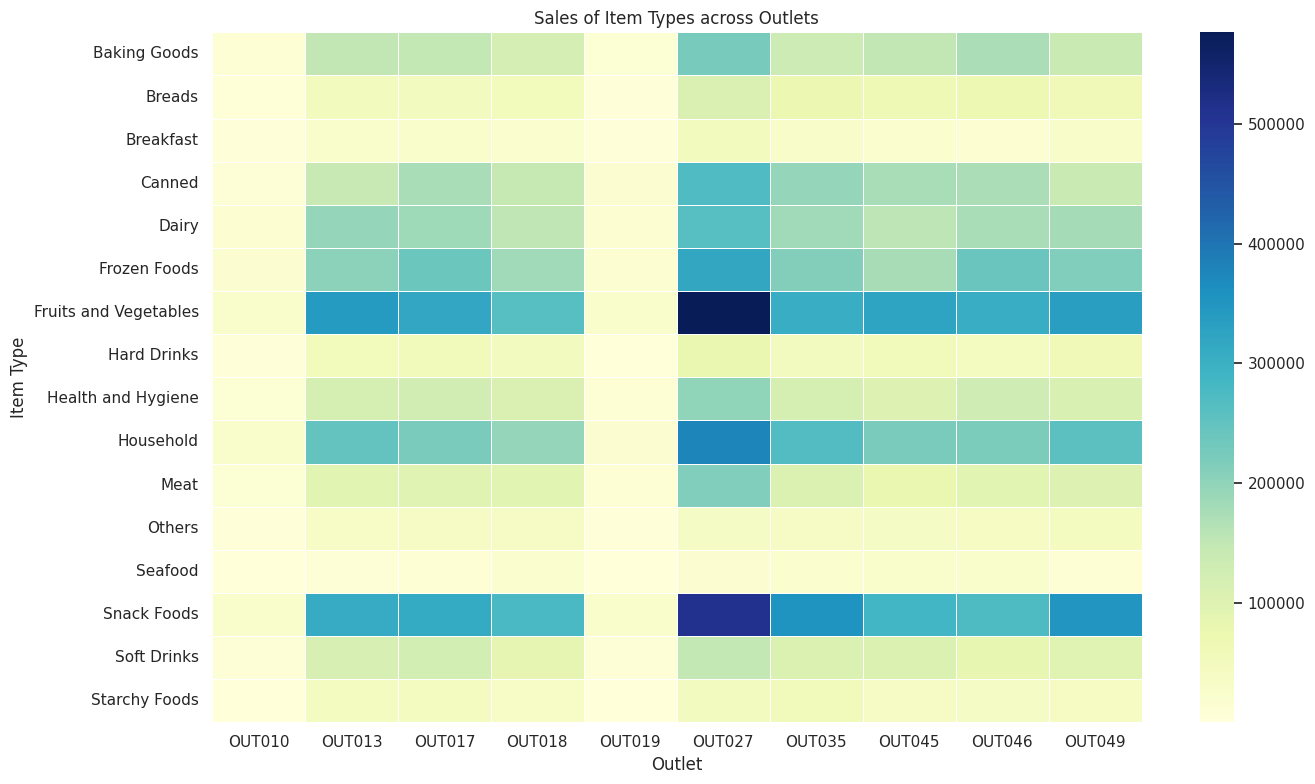

In [ ]:
# Pivot table for heatmap
pivot_heat = grouped.pivot(index='Item_Type', columns='Outlet_Identifier', values='Item_Outlet_Sales').fillna(0)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_heat, cmap='YlGnBu', linewidths=0.5, annot=False)
plt.title('Sales of Item Types across Outlets')
plt.xlabel('Outlet')
plt.ylabel('Item Type')
plt.tight_layout()
plt.show()

    Outlet_Identifier              Item_Type  Item_Outlet_Sales
13             OUT010            Snack Foods         25942.8970
22             OUT013  Fruits and Vegetables        341526.7706
38             OUT017  Fruits and Vegetables        319504.1040
61             OUT018            Snack Foods        278714.5328
77             OUT019            Snack Foods         25653.2740
86             OUT027  Fruits and Vegetables        576028.1886
109            OUT035            Snack Foods        355573.8190
118            OUT045  Fruits and Vegetables        326414.4422
134            OUT046  Fruits and Vegetables        304751.3076
157            OUT049            Snack Foods        350244.0900


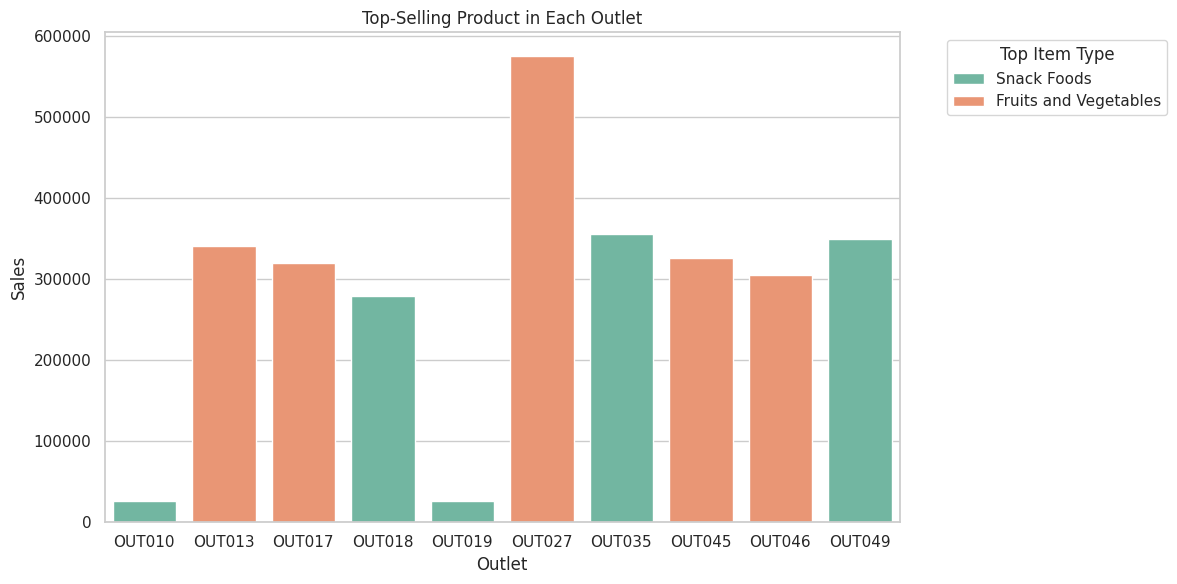

In [ ]:
# Find top selling item type for each outlet
top_products = grouped.loc[grouped.groupby('Outlet_Identifier')['Item_Outlet_Sales'].idxmax()]

print(top_products)

# Display as bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Outlet_Identifier', y='Item_Outlet_Sales', hue='Item_Type', data=top_products, dodge=False, palette='Set2')
plt.title('Top-Selling Product in Each Outlet')
plt.xlabel('Outlet')
plt.ylabel('Sales')
plt.legend(title='Top Item Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 5. Predictive Modeling for Outlet Sales

In [ ]:
df_cleaned["Store_age"]= 2013-df_cleaned['Outlet_Establishment_Year']

In [ ]:
df_cleaned.drop('Outlet_Establishment_Year',axis=1,inplace=True)

In [ ]:
df_cleaned['Item_Identifier'] = df_cleaned['Item_Identifier'].apply(lambda x: x[:2])

In [ ]:
df_cleaned.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Store_age
0,FD,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,Medium,Tier 1,Supermarket Type1,3735.1380,14
1,DR,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,Medium,Tier 3,Supermarket Type2,443.4228,4
2,FD,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,Medium,Tier 1,Supermarket Type1,2097.2700,14
3,FD,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,High,Tier 3,Grocery Store,732.3800,15
4,NC,8.93,Low Fat,0.000000,Household,53.8614,OUT013,High,Tier 3,Supermarket Type1,994.7052,26


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

data_encoded = df_cleaned.copy()

cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    oe = OrdinalEncoder()
    data_encoded[col] = oe.fit_transform(data_encoded[[col]])
    print(oe.categories_)

[array(['DR', 'FD', 'NC'], dtype=object)]
[array(['Low Fat', 'Regular'], dtype=object)]
[array(['Baking Goods', 'Breads', 'Breakfast', 'Canned', 'Dairy',
       'Frozen Foods', 'Fruits and Vegetables', 'Hard Drinks',
       'Health and Hygiene', 'Household', 'Meat', 'Others', 'Seafood',
       'Snack Foods', 'Soft Drinks', 'Starchy Foods'], dtype=object)]
[array(['OUT010', 'OUT013', 'OUT017', 'OUT018', 'OUT019', 'OUT027',
       'OUT035', 'OUT045', 'OUT046', 'OUT049'], dtype=object)]
[array(['High', 'Medium', 'Small'], dtype=object)]
[array(['Tier 1', 'Tier 2', 'Tier 3'], dtype=object)]
[array(['Grocery Store', 'Supermarket Type1', 'Supermarket Type2',
       'Supermarket Type3'], dtype=object)]


In [ ]:
data_encoded

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Store_age
0,1.0,9.300,0.0,0.016047,4.0,249.8092,9.0,1.0,0.0,1.0,3735.1380,14
1,0.0,5.920,1.0,0.019278,14.0,48.2692,3.0,1.0,2.0,2.0,443.4228,4
2,1.0,17.500,0.0,0.016760,10.0,141.6180,9.0,1.0,0.0,1.0,2097.2700,14
3,1.0,19.200,1.0,0.000000,6.0,182.0950,0.0,0.0,2.0,0.0,732.3800,15
4,2.0,8.930,0.0,0.000000,9.0,53.8614,1.0,0.0,2.0,1.0,994.7052,26
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,1.0,6.865,0.0,0.056783,13.0,214.5218,1.0,0.0,2.0,1.0,2778.3834,26
8519,1.0,8.380,1.0,0.046982,0.0,108.1570,7.0,2.0,1.0,1.0,549.2850,11
8520,2.0,10.600,0.0,0.035186,8.0,85.1224,6.0,2.0,1.0,1.0,1193.1136,9
8521,1.0,7.210,1.0,0.145221,13.0,103.1332,3.0,1.0,2.0,2.0,1845.5976,4


In [ ]:
X = data_encoded.drop('Item_Outlet_Sales',axis=1)
y = data_encoded['Item_Outlet_Sales']

In [ ]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100,random_state=42)
scores = cross_val_score(rf,X,y,cv=5,scoring='r2')
print(scores.mean())

0.557761997754519


In [ ]:
from xgboost import XGBRFRegressor

xg = XGBRFRegressor(n_estimators=100,random_state=42)
scores = cross_val_score(xg,X,y,cv=5,scoring='r2')
print(scores.mean())

0.5962927925179724


In [ ]:
xg = XGBRFRegressor(n_estimators=100,random_state=42)

xg1 = xg.fit(X,y)
pd.DataFrame({
    'feature':X.columns,
    'XGBRF_importance':xg1.feature_importances_

}).sort_values(by='XGBRF_importance',ascending=False)


,feature,XGBRF_importance
9,Outlet_Type,0.440799
10,Store_age,0.173503
5,Item_MRP,0.164336
6,Outlet_Identifier,0.152056
8,Outlet_Location_Type,0.033122
7,Outlet_Size,0.025899
1,Item_Weight,0.003410
3,Item_Visibility,0.003083
4,Item_Type,0.002128
0,Item_Identifier,0.001100


In [ ]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [ ]:
from xgboost import XGBRFRegressor

xg = XGBRFRegressor(n_estimators=100,random_state=42)
scores = cross_val_score(xg1,X.drop(['Item_Fat_Content','Item_Identifier','Item_Visibility', 'Item_Type','Outlet_Location_Type'],axis=1),y,cv=5,scoring='r2')
print(scores.mean())

0.5963750747121016


In [ ]:
final_data = X.drop(['Item_Fat_Content','Item_Identifier','Item_Visibility', 'Item_Type','Outlet_Location_Type'],axis=1)


In [ ]:
from xgboost import XGBRFRegressor
xg_final = XGBRFRegressor()
xg_final.fit(final_data,y)

XGBRFRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bytree=None, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, objective='reg:squarederror',
               random_state=None, ...)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

X_train,X_test,y_train,y_test = train_test_split(final_data,y,
                                                 test_size=0.20,
                                                 random_state=42)
xg_final.fit(X_train,y_train)

XGBRFRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bytree=None, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, objective='reg:squarederror',
               random_state=None, ...)

In [ ]:
y_pred = xg_final.predict(X_test)
mean_absolute_error(y_test,y_pred)

714.7294112778935

In [ ]:
from sklearn.metrics import mean_squared_error

print('RMSE:',np.sqrt(mean_squared_error(y_test, y_pred)))



RMSE: 1019.726205054867


In [ ]:
from sklearn.metrics import r2_score
print(r2_score(y_test,y_pred))

0.6174197994130319


In [ ]:
y_test

,Item_Outlet_Sales
7503,1743.0644
2957,356.8688
7031,377.5086
1084,5778.4782
856,2356.9320
...,...
7205,3004.0896
3257,890.8404
6346,629.1810
6318,253.0040


In [ ]:
pred = xg_final.predict(np.array([[141.6180,9.0,1.0,1.0,1.0,24]]))[0]
print(pred)

727.9872
